In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取图像

In [2]:
filename = "imgs/pca.jpg"
img = cv2.imread(filename)

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

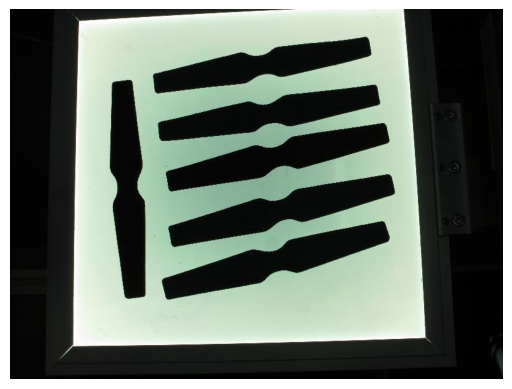

In [3]:
plt.imshow(img)
plt.axis("off")

# 2. 轮廓处理

In [4]:
# 灰度图像
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# 二值化图像(第一个参数返回优化的阈值)
_, img_bin = cv2.threshold(img_gray, 50,255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
# 抽取轮廓（发现目标）
contours, _ = cv2.findContours(img_bin, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
# 循环处理轮廓
for i in range(len(contours)):
    # 获取轮廓的面积，面积过大过小都不绘制
    area = cv2.contourArea(contours[i])
    if area < 0.001 or area >20000:
        continue

    # 绘制轮廓
    cv2.drawContours(img, contours, i, (0, 0, 255), 3)
    # 计算每个目标的方向

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

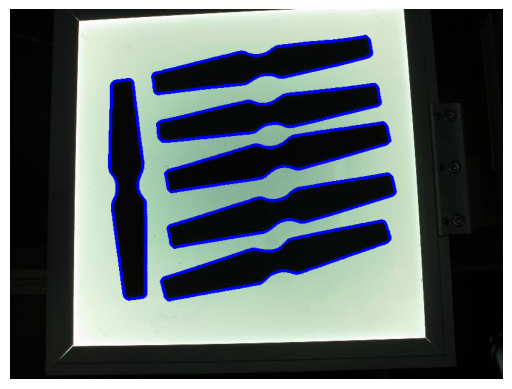

In [5]:
plt.imshow(img)
plt.axis("off")

# 3. 侦测方向

In [6]:
print(contours[0].shape)
print(len(contours))

(786, 1, 2)
7


In [7]:
for contour in contours[0:-1]:
    # 先把contour处理成二维数据(中间那一维去掉)
    data = np.squeeze(contour).astype(float)  # 下面需要浮点数才能运算
    # 计算均值中心点
    c_x, c_y = np.mean(data, axis=0)
    # 计算特征值与特征向量
    _, e_vec, e_val = cv2.PCACompute2(data, np.mean(data, axis=0).reshape(1, -1)) 
    # print(e_val)
    # 绘制中心点
    img = cv2.circle(img, (int(c_x), int(c_y)), 5, (255, 0, 0), 3)
    # 计算坐标轴的另外一个端点
    p1_x = int(c_x + e_vec[0][0] * e_val[0][0] * 0.015)  # 缩小0.015
    p1_y = int(c_y + e_vec[0][1] * e_val[0][0] * 0.015)
    
    
    p2_x = int(c_x + e_vec[1][0] * e_val[1][0] * 0.08)
    p2_y = int(c_y + e_vec[1][1] * e_val[1][0] * 0.08)
    
    # 绘制两个坐标轴
    cv2.arrowedLine(img, pt1=(int(c_x), int(c_y)), pt2=(p1_x, p1_y), color=(255, 0, 0), thickness=2, tipLength=0.05)
    cv2.arrowedLine(img, pt1=(int(c_x), int(c_y)), pt2=(p2_x, p2_y), color=(255, 0, 0), thickness=2, tipLength=0.05)

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

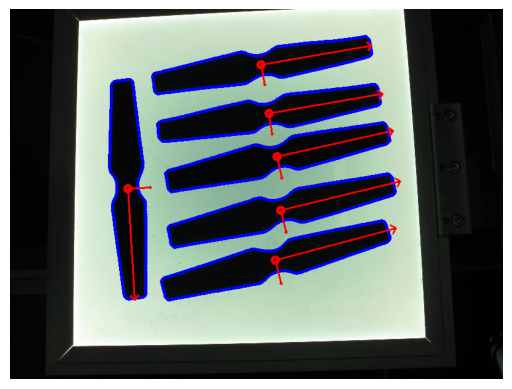

In [8]:
plt.imshow(img)
plt.axis("off")